## 2 Whisper Baseline

This notebook will get the baseline WER and CER scores for Romansh. For this the test set each idiom will be decoded with both OpenAI's Whisper.

In [1]:
import sys
from pathlib import Path

notebook_dir = Path.cwd()
whisper_dir = notebook_dir.parent
sys.path.append(str(whisper_dir))

import torch
import random
from transformers import WhisperProcessor, WhisperForConditionalGeneration

from whisper_asr import (
  transcribe_whisper, compute_wer, compute_cer, 
  plot_wer_violin,load_all_data, compute_idiom_results, 
  print_evaluation_results, normalize_romansh_text
)
from whisper_asr.utils import get_best_gpu

/local/scratch/matuor/whisper/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


For now we will use the Whisper Medium, the constants can however be changed to use any other model.

In [2]:
WHISPER_MODEL = "medium"
BATCH_SIZE = 8

DEVICE = torch.device(f"cuda:{get_best_gpu()}" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Selected GPU 5 with 24121 MiB free memory
Using device: cuda:5


First we load all the test data and concatenate it to one dataframe.

In [3]:
df_test = load_all_data("test")
print(f"\nTotal test samples: {len(df_test)}")
df_test.sample(10)


Total test samples: 631


,audio_path,sentence,idiom
122,/local/scratch/matuor/data/clean-data/rmsursil...,cu sche buca uss china unda verda cun demonstr...,Sursilvan
89,/local/scratch/matuor/data/clean-data/rmsursil...,hemmiga da stefan eicher e gie cun quellas ret...,Sursilvan
76,/local/scratch/matuor/data/clean-data/rm-cc-20...,la destinaziun da vacanzas sedrun muster turis...,RG
286,/local/scratch/matuor/data/clean-data/rmputer-...,bernhard russi guadagna or illa cuorsa val la ...,Puter
393,/local/scratch/matuor/data/clean-data/rmsutsil...,igl carstgan fora lura antocen 6 kilometers tr...,Sutsilvan
556,/local/scratch/matuor/data/clean-data/rmsursiv...,en de vainsa catto en med da communicaziun ide...,Surmiran
357,/local/scratch/matuor/data/clean-data/rmputer-...,cu sune stedas tias vacanzas vulessane savair ...,Puter
202,/local/scratch/matuor/data/clean-data/rmvallad...,il grischun as muossa da sia plu bella vart il...,Vallader
293,/local/scratch/matuor/data/clean-data/rmputer-...,ils pucks sun gnieus dos invi ed inno daspo an...,Puter
218,/local/scratch/matuor/data/clean-data/rmvallad...,71 ons hal lavura hal sco pitur e fat la scoul...,Vallader


Then we can start transcribing with Whisper.

In [4]:
print("Loading Whisper model...")
processor = WhisperProcessor.from_pretrained(f"openai/whisper-{WHISPER_MODEL}")
model = WhisperForConditionalGeneration.from_pretrained(f"openai/whisper-{WHISPER_MODEL}")

print("Transcribing with Whisper...")
whisper_transcriptions = transcribe_whisper(
    model=model,
    processor=processor,
    audio_paths=df_test["audio_path"].tolist(),
    batch_size=BATCH_SIZE,
    device=DEVICE
)

df_test['transcriptions'] = whisper_transcriptions
print("Whisper transcription complete.")

Loading Whisper model...


Loading weights: 100%|██████████| 947/947 [00:00<00:00, 4701.52it/s]


Transcribing with Whisper...


/local/scratch/matuor/whisper/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:829: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
Transcribing (Whisper):   0%|          | 0/79 [00:00<?, ?it/s]The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.

Whisper transcription complete.


Before evaluating we normalize the sentences transcribed by Whisper. Since Whisper is not trained on Romansh it is not surprising that the baseline scores are poor.

In [5]:
df_test['transcriptions'] = df_test['transcriptions'].apply(normalize_romansh_text)
references = df_test['sentence']
transcriptions = df_test['transcriptions']
idioms = df_test['idiom']

summary_df, overall_wer, overall_cer, valid_pairs = compute_idiom_results(references, transcriptions, idioms)
print_evaluation_results(summary_df, overall_wer, overall_cer, len(df_test['audio_path']), len(valid_pairs))


OVERALL RESULTS
Total test samples: 631
Valid pairs: 631/631

Word Error Rate (WER): 0.9797 (97.97%)
Character Error Rate (CER): 0.5540 (55.40%)

PER IDIOM RESULTS

RG
  Samples: 81
  WER: 0.8923 (89.23%)
  CER: 0.5037 (50.37%)

SURSILVAN
  Samples: 94
  WER: 0.9808 (98.08%)
  CER: 0.5478 (54.78%)

VALLADER
  Samples: 97
  WER: 0.9312 (93.12%)
  CER: 0.5117 (51.17%)

PUTER
  Samples: 114
  WER: 0.9491 (94.91%)
  CER: 0.5230 (52.30%)

SUTSILVAN
  Samples: 94
  WER: 1.0668 (106.68%)
  CER: 0.6761 (67.61%)

SURMIRAN
  Samples: 151
  WER: 1.0469 (104.69%)
  CER: 0.5601 (56.01%)

SUMMARY TABLE
    idiom  samples      wer      cer
       RG       81 0.892344 0.503687
Sursilvan       94 0.980826 0.547799
 Vallader       97 0.931177 0.511684
    Puter      114 0.949126 0.522975
Sutsilvan       94 1.066826 0.676138
 Surmiran      151 1.046939 0.560136


/local/scratch/matuor/whisper/whisper_asr/analysis.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/local/scratch/matuor/whisper/whisper_asr/analysis.py:39: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


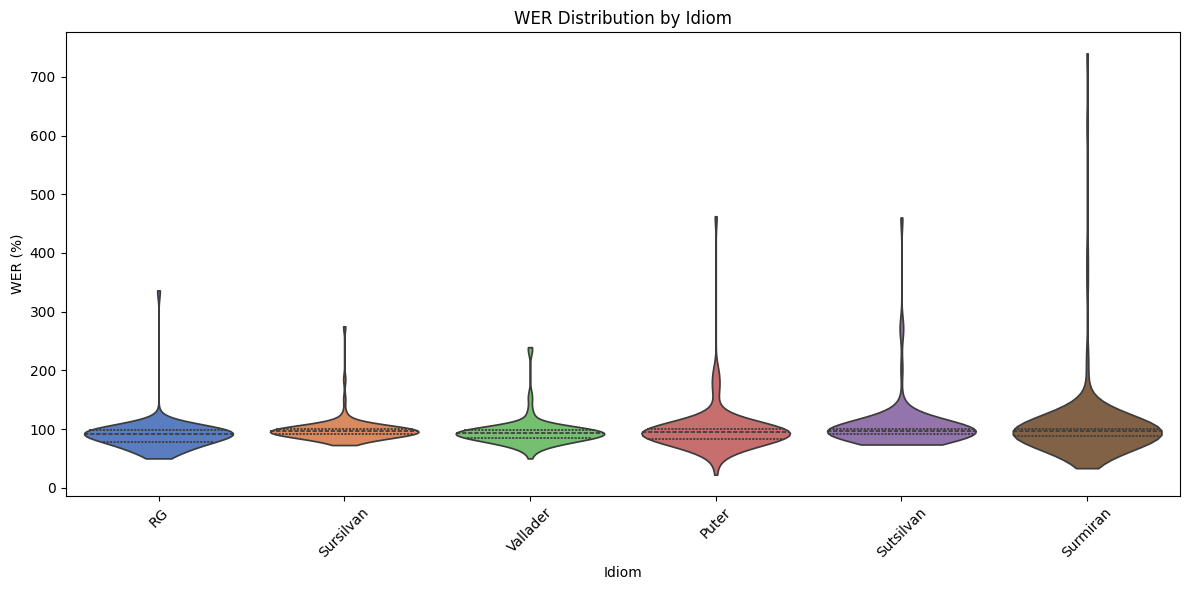

In [6]:
plot_wer_violin(references, transcriptions, idioms)

From the example transcriptions it becomes clear that Whisper is not trained on Romansh so it will just automatically detect a wrong language and then transcribe for that language.

In [7]:
sample_indices = random.sample(range(len(valid_pairs)), min(5, len(valid_pairs)))

for i, idx in enumerate(sample_indices):
    print(f"--- Sample {i} ---")
    print(f"Idiom: {idioms[idx]}")
    print(f"Reference: {references[idx]}")
    print(f"Hypothesis: {transcriptions[idx]}")
    sample_wer, sample_cer = compute_wer(references[idx], transcriptions[idx]), compute_cer(references[idx], transcriptions[idx])
    print(f"Sample WER: {sample_wer:.4f}, Sample CER: {sample_cer:.4f}")
    print("-" * 40)

--- Sample 0 ---
Idiom: Surmiran
Reference: tge e alloura en tractor den pour ehm en pour savess ossa betg duvrar chella maschina co
Hypothesis: en dat je dan een tractor kan doen een tractor is een bedoelbaar aardig dat je de machine kan
Sample WER: 1.0588, Sample CER: 0.6591
----------------------------------------
--- Sample 1 ---
Idiom: Surmiran
Reference: ma la gronda part e schon stos naturalmaintg exponents digl turissem also betg gion gieri maria e madlaina mabagn propi persungas eh tgi on da far ple u manc direct ensatge cun las pendicularas grischunas ni cugl turissem grischun las pendicularas tgi on gio er anvido e schi chels exponents on forsa spitgia tgi detta commitments clers per lour branscha alloura stoia deir na ogl betg do oter tgi chellas ea chellas tgi ins canoscha schon
Hypothesis: maer gronfa fath or sion stos yn y traf yn y cysponent ddiddorisme ales o beth yw john gier maria ym mardlaen yn ymwneud ar proses yma maen deall bod yn ffyrdd yn ystod ymlaen yn y ddid